# Side-by-Side Prints for Reports (2016 and 2021)

In [21]:
import openeo
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from shapely.geometry import Point
from shapely.ops import transform
import rasterio
import tempfile
import warnings
from rasterio.transform import from_origin

In [ ]:
# -----------------------------
# PARAMETERS
# -----------------------------
AOI_PATH = "../data/aoi/2025_aoi.geojson"
OUTPUT_DIR = "../data/results/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Define year ranges to process
YEARS = {
    "2016": ["2016-06-01", "2016-08-31"],
    "2017": ["2017-06-01", "2017-08-31"],
    "2018": ["2018-06-01", "2018-08-31"],
    "2019": ["2019-06-01", "2019-08-31"],
    "2020": ["2020-06-01", "2020-08-31"],
    "2021": ["2021-06-01", "2021-08-31"]
}

# extract year from start date
# YEAR = START_DATE[:4]

# -----------------------------
# SENSORS CONFIG (automatic collection switch)
# -----------------------------
SENSORS = {
    "Sentinel-2": {
        "id": "SENTINEL2_L1C",
        "rgb_bands": ["B04","B03","B02"],
        "ndwi_bands": ["B03","B08"],
        "cloud_cover_max": 20  # relaxed for northern areas
    },
    "Landsat-8": {
        "id": "LANDSAT8-9_L2",
        "rgb_bands": ["B04","B03","B02"],
        "ndwi_bands": ["B03","B05"],
        "cloud_cover_max": 20
    }
}

# -----------------------------
# CONNECT TO OPENEO BACKEND
# -----------------------------
connection = openeo.connect("openeo.vito.be").authenticate_oidc()

Authenticated using refresh token.


In [27]:
# -----------------------------
# LOAD AOI
# -----------------------------
aoi = gpd.read_file(AOI_PATH)
geom_type = aoi.geometry.iloc[0].geom_type
if geom_type == "Point":
    print("AOI is a Point; buffering to create a Polygon...")
    aoi.geometry = aoi.geometry.buffer(0.05)  # ~5 km buffer
aoi_geom = aoi.geometry.values[0].__geo_interface__

AOI is a Point; buffering to create a Polygon...


In [28]:
# -----------------------------
# HELPER FUNCTIONS
# -----------------------------
def find_best_scene(sensor, bands, start_date, end_date):
    return connection.load_collection(
        sensor["id"],
        spatial_extent=aoi_geom,
        temporal_extent=[start_date, end_date],
        bands=bands,
        max_cloud_cover=sensor["cloud_cover_max"]
    )

def download_array(coll):
    tmp_file = tempfile.NamedTemporaryFile(suffix=".tif", delete=False).name
    coll.download(tmp_file)
    with rasterio.open(tmp_file) as src:
        arr = src.read()  # shape: bands, rows, cols
        transform = src.transform
        crs = src.crs
    try:
        os.remove(tmp_file)
    except Exception:
        pass
    return np.transpose(arr, (1,2,0)), transform, crs  # HWC, transform, CRS

def apply_data_mask(rgb_arr, mask_arr):
    rgb = rgb_arr.astype(float).copy()
    if mask_arr is None:
        return rgb
    mask_bool = (mask_arr > 0)
    if mask_bool.shape != rgb.shape[:2]:
        return rgb
    rgb[~mask_bool] = np.nan
    return rgb

def linear_percent_stretch(rgb, lower_percent=2, upper_percent=98):
    out = np.empty_like(rgb, dtype=float)
    for i in range(rgb.shape[2]):
        band = rgb[:,:,i]
        low, high = np.nanpercentile(band, [lower_percent, upper_percent])
        if np.isfinite(low) and np.isfinite(high) and (high - low) > 1e-6:
            out[:,:,i] = np.clip((band - low) / (high - low), 0, 1)
        else:
            mx = np.nanmax(band)
            if mx > 0:
                out[:,:,i] = np.clip(band / mx, 0, 1)
            else:
                out[:,:,i] = band
    return out

def gamma_correction(rgb, gamma=1.2):
    if gamma is None or gamma == 1.0:
        return rgb
    rgb = np.clip(rgb, 0, 1)
    return np.power(rgb, 1.0/gamma)

def prepare_rgb_for_display(rgb_arr, data_mask=None, lower_percent=2, upper_percent=98, gamma=1.2):
    rgb = apply_data_mask(rgb_arr, data_mask)
    stretched = linear_percent_stretch(rgb, lower_percent, upper_percent)
    corrected = gamma_correction(stretched, gamma=gamma)
    return np.nan_to_num(corrected, nan=0.0)

def try_download_datamask(sensor, start_date, end_date):
    try:
        mask_coll = connection.load_collection(
            sensor["id"],
            spatial_extent=aoi_geom,
            temporal_extent=[start_date, end_date],
            bands=["dataMask"],
            max_cloud_cover=sensor["cloud_cover_max"]
        )
        mask_arr, _, _ = download_array(mask_coll)
        if mask_arr.ndim == 3 and mask_arr.shape[2] >= 1:
            return mask_arr[:,:,0]
        else:
            return None
    except Exception as e:
        warnings.warn(f"dataMask download failed for {sensor['id']}: {e}")
        return None

def save_raster(arr, sensor_name, year, suffix, transform, crs, dtype=None):
    if arr is None:
        print(f"No data to save for {sensor_name} {suffix} {year}")
        return
    if dtype is None:
        dtype = arr.dtype
    height, width = arr.shape[:2]
    out_path = os.path.join(OUTPUT_DIR, f"{sensor_name.lower().replace('-','')}_{suffix}_{year}.tif")
    with rasterio.open(
        out_path,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=1,
        dtype=dtype,
        crs=crs,
        transform=transform
    ) as dst:
        dst.write(arr.astype(dtype), 1)
    print(f"Saved {out_path}")


=== Processing year 2016 (2016-06-01 → 2016-08-31) ===

Processing Sentinel-2...
Saved ../data/results/sentinel2_ndwi_2016.tif
Saved ../data/results/sentinel2_watermask_2016.tif
Processing Landsat-8...
Saved ../data/results/landsat8_ndwi_2016.tif
Saved ../data/results/landsat8_watermask_2016.tif


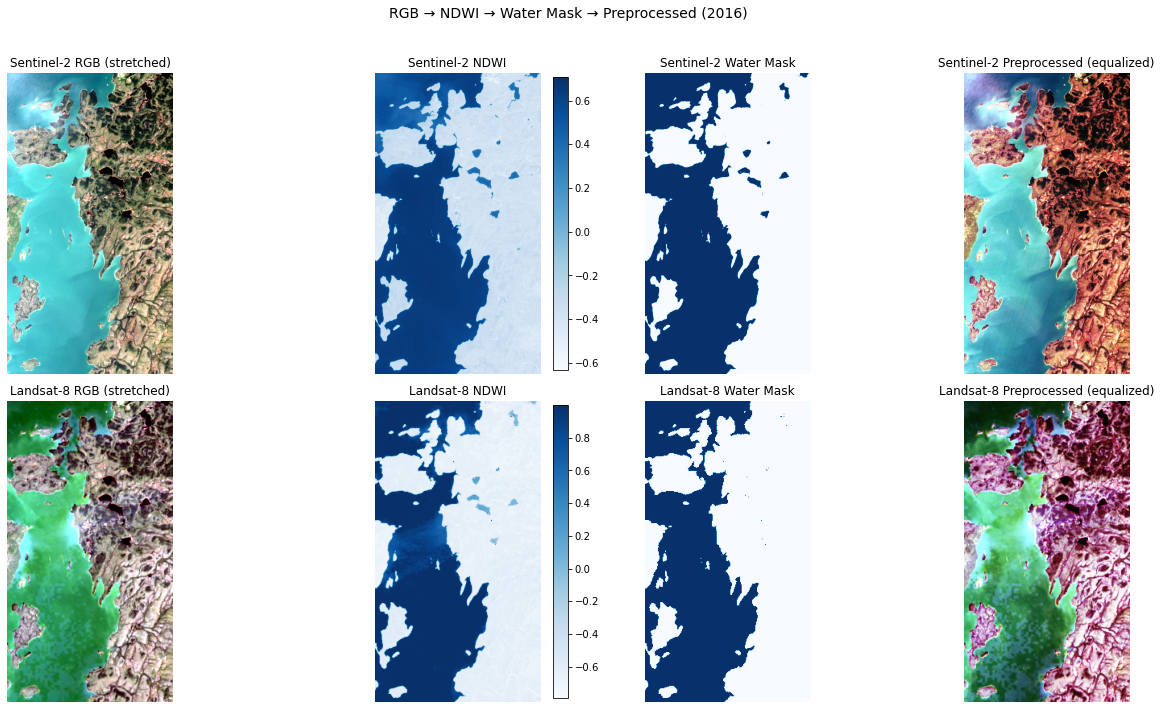


=== Processing year 2021 (2021-06-01 → 2021-08-31) ===

Processing Sentinel-2...
Saved ../data/results/sentinel2_ndwi_2021.tif
Saved ../data/results/sentinel2_watermask_2021.tif
Processing Landsat-8...
Saved ../data/results/landsat8_ndwi_2021.tif
Saved ../data/results/landsat8_watermask_2021.tif


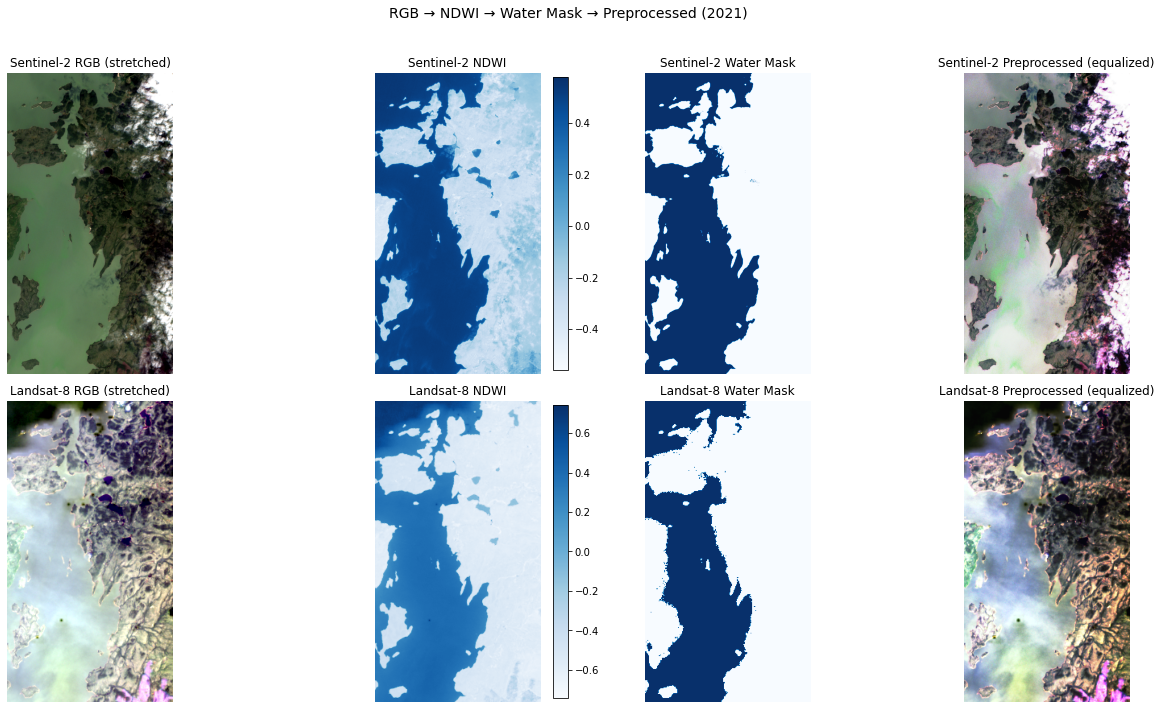

In [ ]:
# -----------------------------
# MAIN PROCESS LOOP
# -----------------------------
for year, (start_date, end_date) in YEARS.items():
    print(f"\n=== Processing year {year} ({start_date} → {end_date}) ===\n")
    results = {}
    for name, sensor in SENSORS.items():
        print(f"Processing {name}...")
        # -----------------------------
        # Create sensor-specific folder
        # -----------------------------
        sensor_folder = os.path.join(OUTPUT_DIR, name.lower().replace('-', ''))
        os.makedirs(sensor_folder, exist_ok=True)

        data_mask = try_download_datamask(sensor, start_date, end_date)

        # RGB
        try:
            rgb_coll = find_best_scene(sensor, sensor["rgb_bands"], start_date, end_date)
            rgb_img, _, _ = download_array(rgb_coll)
            rgb_display = prepare_rgb_for_display(rgb_img, data_mask=data_mask,
                                                  lower_percent=2, upper_percent=98, gamma=1.2)
        except Exception as e:
            warnings.warn(f"Failed to download RGB for {name}: {e}")
            rgb_img, rgb_display = None, None

        # NDWI + water mask
        try:
            ndwi_coll = find_best_scene(sensor, sensor["ndwi_bands"], start_date, end_date)
            ndwi_bands, transform, crs = download_array(ndwi_coll)
            if ndwi_bands.ndim == 3 and ndwi_bands.shape[2] >= 2:
                green = ndwi_bands[:,:,0].astype(float)
                nir   = ndwi_bands[:,:,1].astype(float)
                ndwi_arr = (green - nir) / (green + nir + 1e-10)
                water_mask = (ndwi_arr > 0.3).astype(np.uint8)
            else:
                raise ValueError("Downloaded NDWI bands not shape HxWx2")
        except Exception as e:
            warnings.warn(f"Failed to compute NDWI for {name}: {e}")
            ndwi_arr, water_mask = None, None
            transform, crs = None, "EPSG:4326"

        results[name] = {
            "RGB_raw": rgb_img,
            "RGB_display": rgb_display,
            "NDWI": ndwi_arr,
            "Water": water_mask,
            "transform": transform,
            "crs": crs
        }

        # Save NDWI
        out_ndwi = os.path.join(sensor_folder, f"{name.lower().replace('-','')}_ndwi_{year}.tif")
        save_raster(ndwi_arr, name, year, "ndwi", transform, crs, dtype=np.float32, out_file=out_ndwi)

        # Save water mask
        out_mask = os.path.join(sensor_folder, f"{name.lower().replace('-','')}_watermask_{year}.tif")
        save_raster(water_mask, name, year, "watermask", transform, crs, dtype=np.uint8, out_file=out_mask)


    # OPTIONAL: plot summary
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    sensor_order = ["Sentinel-2", "Landsat-8"]
    for r, sname in enumerate(sensor_order):
        res = results.get(sname, {})
        safe_imshow(axes[r,0], res.get("RGB_display"), title=f"{sname} RGB (stretched)")
        safe_imshow(axes[r,1], res.get("NDWI"), cmap="Blues", title=f"{sname} NDWI", colorbar=True)
        safe_imshow(axes[r,2], res.get("Water"), cmap="Blues", title=f"{sname} Water Mask")
        preproc = None
        if res.get("RGB_raw") is not None:
            raw = res["RGB_raw"].astype(float)
            he = np.empty_like(raw, dtype=float)
            for i in range(raw.shape[2]):
                band = raw[:,:,i]
                stretched = linear_percent_stretch(band[:,:,None], 2, 98)[:,:,0]
                hist, bins = np.histogram(stretched.flatten(), bins=256, range=(0,1))
                cdf = hist.cumsum() / hist.cumsum()[-1]
                he[:,:,i] = np.interp(stretched.flatten(), bins[:-1], cdf).reshape(stretched.shape)
            preproc = np.nan_to_num(he)
        safe_imshow(axes[r,3], preproc, title=f"{sname} Preprocessed (equalized)")

    plt.suptitle(f"RGB → NDWI → Water Mask → Preprocessed ({year})", fontsize=14)
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.savefig(os.path.join(OUTPUT_DIR, f"comparison_{year}.png"), dpi=300)
    plt.show()

In [30]:
for sname in sensor_order:
    res = results[sname]
    # Slide 2: RGB
    rgb_display = res.get("RGB_display")
    if rgb_display is not None:
        plt.imsave(f"{OUTPUT_DIR}/{sname.lower()}_rgb_{START_DATE[:4]}.png", rgb_display)
    # Slide 5: Preprocessed RGB
    preproc = None
    if res.get("RGB_raw") is not None:
        raw = res["RGB_raw"].astype(float)
        he = np.empty_like(raw, dtype=float)
        for i in range(raw.shape[2]):
            band = raw[:,:,i]
            stretched = linear_percent_stretch(band[:,:,None], 2, 98)[:,:,0]
            hist, bins = np.histogram(stretched.flatten(), bins=256, range=(0,1))
            cdf = hist.cumsum()
            cdf = cdf / cdf[-1]
            he[:,:,i] = np.interp(stretched.flatten(), bins[:-1], cdf).reshape(stretched.shape)
        preproc = np.nan_to_num(he)
        plt.imsave(f"{OUTPUT_DIR}/{sname.lower()}_preproc_{START_DATE[:4]}.png", preproc)


In [ ]:
import matplotlib.pyplot as plt
import os

OUTPUT_DIR = "../data/results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

sensor_order = ["Sentinel-2", "Landsat-8"]

for year, dates in YEARS.items():
    start_date, end_date = dates
    print(f"=== Creating combined figures for year {year} ({start_date} → {end_date}) ===")

    for sname in sensor_order:
        res = results.get(sname, {})
        
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        
        # -----------------
        # Slide 2: RGB display
        # -----------------
        rgb_display = res.get("RGB_display")
        if rgb_display is not None:
            axes[0].imshow(rgb_display)
            axes[0].set_title("RGB Display")
            axes[0].axis("off")
        else:
            axes[0].text(0.5,0.5,"No data", ha="center", va="center")
            axes[0].axis("off")
        
        # -----------------
        # Slide 3: NDWI
        # -----------------
        ndwi_arr = res.get("NDWI")
        if ndwi_arr is not None:
            im = axes[1].imshow(ndwi_arr, cmap="Blues")
            axes[1].set_title("NDWI")
            axes[1].axis("off")
            fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
        else:
            axes[1].text(0.5,0.5,"No data", ha="center", va="center")
            axes[1].axis("off")
        
        # -----------------
        # Slide 4: Water mask
        # -----------------
        water_mask = res.get("Water")
        if water_mask is not None:
            axes[2].imshow(water_mask, cmap="Blues")
            axes[2].set_title("Water Mask")
            axes[2].axis("off")
        else:
            axes[2].text(0.5,0.5,"No data", ha="center", va="center")
            axes[2].axis("off")
        
        # -----------------
        # Slide 5: Preprocessed RGB
        # -----------------
        preproc = None
        if res.get("RGB_raw") is not None:
            raw = res["RGB_raw"].astype(float)
            he = np.empty_like(raw, dtype=float)
            for i in range(raw.shape[2]):
                band = raw[:,:,i]
                stretched = linear_percent_stretch(band[:,:,None], 2, 98)[:,:,0]
                hist, bins = np.histogram(stretched.flatten(), bins=256, range=(0,1))
                cdf = hist.cumsum()
                cdf = cdf / cdf[-1]
                he[:,:,i] = np.interp(stretched.flatten(), bins[:-1], cdf).reshape(stretched.shape)
            preproc = np.nan_to_num(he)
            axes[3].imshow(preproc)
            axes[3].set_title("Preprocessed RGB")
            axes[3].axis("off")
        else:
            axes[3].text(0.5,0.5,"No data", ha="center", va="center")
            axes[3].axis("off")
        
        plt.suptitle(f"{sname} - Year {year}", fontsize=16)
        plt.tight_layout(rect=[0,0,1,0.95])
        
        # -----------------
        # Save combined figure in sensor-specific folder
        # -----------------
        sensor_folder = os.path.join(OUTPUT_DIR, sname.lower().replace('-', ''))
        os.makedirs(sensor_folder, exist_ok=True)  # create folder if it doesn't exist
        out_file = os.path.join(sensor_folder, f"{sname.lower().replace('-', '')}_slides_{year}.png")
        plt.savefig(out_file, dpi=300, bbox_inches='tight')
        plt.close(fig)
        print(f"Saved combined slides figure: {out_file}")

=== Creating combined figures for year 2016 (2016-06-01 → 2016-08-31) ===
Saved combined slides figure: ../data/results/sentinel2_slides_2016.png
Saved combined slides figure: ../data/results/landsat8_slides_2016.png
=== Creating combined figures for year 2021 (2021-06-01 → 2021-08-31) ===
Saved combined slides figure: ../data/results/sentinel2_slides_2021.png
Saved combined slides figure: ../data/results/landsat8_slides_2021.png
